In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dynamic Pricing using Bandits

## The demand curve

### **Assumptions**: I am the only one selling this item (monopoly), I have infinite availability, and $n_t$ customers show up at day $t$.

### Single customer:

In [2]:
price = 15
conversion_probability = lambda p: 1-p/20

sold = np.random.binomial(1, conversion_probability(price))

print(f'Probability of purchase at price {price}: {conversion_probability(price)}')

# will the customer buy my product at this price?
print(f'Sold? {bool(sold)}')

Probability of purchase at price 15: 0.25
Sold? False


### Multiple customers:

In [3]:
n_customers = 100

sales = np.random.binomial(n_customers, conversion_probability(price))

# will the customer buy my product at this price?
print(f'How many sales? {sales}')

How many sales? 24


### Expectation over multiple customers:

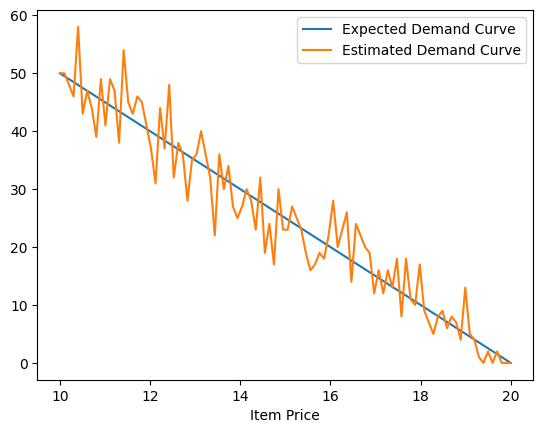

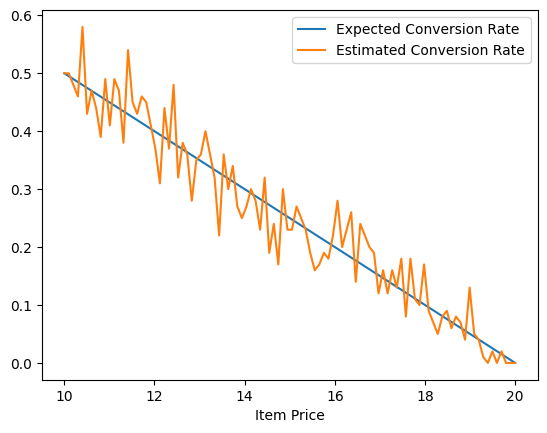

In [4]:
prices = np.linspace(10, 20, 100)
n_customers = 100 # what happens if you increase n?

expected_demand_curve = n_customers*conversion_probability(prices)

estimated_demand_curve = np.random.binomial(n_customers, conversion_probability(prices))

plt.figure()
plt.plot(prices, expected_demand_curve, label='Expected Demand Curve')
plt.plot(prices, estimated_demand_curve, label='Estimated Demand Curve')
plt.xlabel('Item Price')
plt.legend()
plt.show()

plt.figure()
plt.plot(prices, expected_demand_curve/n_customers, label='Expected Conversion Rate')
plt.plot(prices, estimated_demand_curve/n_customers, label='Estimated Conversion Rate')
plt.xlabel('Item Price')
plt.legend()
plt.show()

### How can I compute my profit?

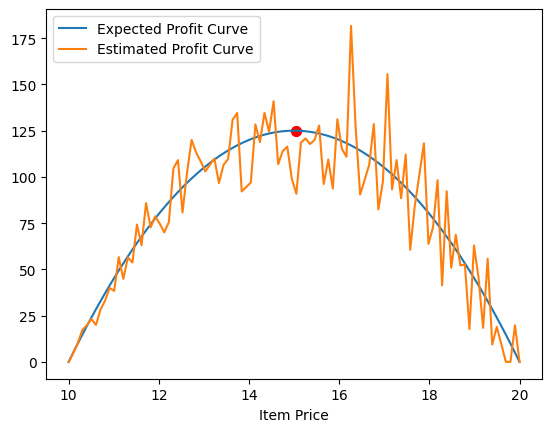

In [5]:
cost = 10

expected_profit_curve = n_customers*conversion_probability(prices)*(prices-cost)

estimated_profit_curve = np.random.binomial(n_customers, conversion_probability(prices))*(prices-cost)

best_price_index = np.argmax(expected_profit_curve)
best_price = prices[best_price_index]

plt.figure()
plt.plot(prices, expected_profit_curve, label='Expected Profit Curve')
plt.plot(prices, estimated_profit_curve, label='Estimated Profit Curve')
plt.scatter(best_price, expected_profit_curve[best_price_index], color='red', s=50)
plt.xlabel('Item Price')
plt.legend()
plt.show();

In [6]:
best_price

np.float64(15.05050505050505)

### How can I find the better price, while maximizing my cumulative profits? -> Exploration-Exploitation trade-off -> Online Learning!

### Things to pay atention to when designing a toy example:
- ### The conversion rate should be in [0,1], i.e., $\alpha(p) \in [0,1] \;\forall p \in [p_{\text{min}},p_{\text{max}}]$
- ### The reward function must not "degenerate" (the optimum must not be $p_{\text{min}}$ or $p_{\text{max}}$)
- ### The minimum price must be larger than or equal to the cost
#### Examples of BAD instances:

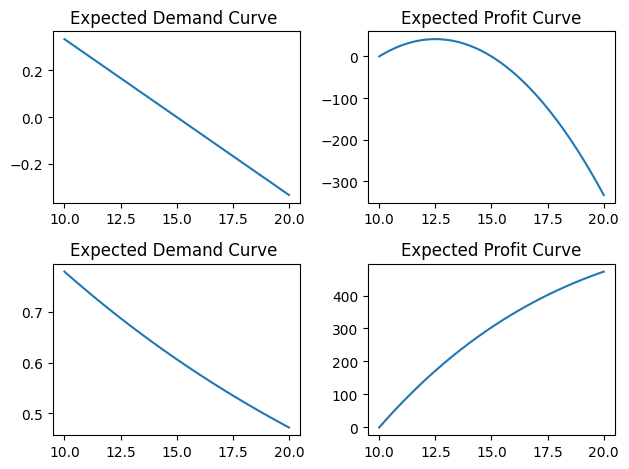

In [ ]:
prices = np.linspace(10, 20, 100)
n_customers = 100
conversion_probability
expected_demand_curve = n_customers*conversion_probability(prices)
fig, axs = plt.subplots(2, 2) 

conversion_probability = lambda p: 1-p/15 # observe that it is negative in (15,20]
axs[0, 0].plot(prices, conversion_probability(prices), label='Conversion Probability')
axs[0, 0].set_title("Expected Demand Curve ")
axs[0, 1].plot(prices, n_customers*conversion_probability(prices)*(prices-cost), label='Expected Demand Curve')
axs[0, 1].set_title("Expected Profit Curve")

conversion_probability = lambda p: np.exp(-0.05*(p-5)) # observe that you can increase the price!
# conversion_probability = lambda p: np.exp(-0.3*(p-8))
axs[1, 0].plot(prices, conversion_probability(prices), label='Conversion Probability')
axs[1, 0].set_title("Expected Demand Curve ")
axs[1, 1].plot(prices, n_customers*conversion_probability(prices)*(prices-cost), label='Expected Demand Curve')
axs[1, 1].set_title("Expected Profit Curve")

plt.tight_layout()
plt.show()

### Let's formalize the environment:

In [8]:
class PricingEnvironment:
    def __init__(self, conversion_probability, cost):
        self.conversion_probability = conversion_probability
        self.cost = cost

    def round(self, p_t, n_t):
        d_t = np.random.binomial(n_t, self.conversion_probability(p_t))
        r_t = (p_t - self.cost)*d_t
        return d_t, r_t
    
    

In [9]:
env = PricingEnvironment(conversion_probability=conversion_probability, cost=5)
env.round(10, 100)

(77, 385)

### Extra: try to modify the environment to allow for seed fixing, in order to make the simulations entirely reproducible (use a generator)

## Naive Approach: Discretization

### Idea: I partition possible prices in a discrete number, then use a standard MAB algorithm such as UCB1

In [10]:
class UCB1Agent:
    def __init__(self, K, T, range=1):
        self.K = K
        self.T = T
        self.range = range
        self.a_t = None
        self.average_rewards = np.zeros(K)
        self.N_pulls = np.zeros(K)
        self.t = 0
    
    def pull_arm(self):
        if self.t < self.K:
            self.a_t = self.t 
        else:
            ucbs = self.average_rewards + self.range*np.sqrt(np.log(self.T)/(2*self.N_pulls))
            self.a_t = np.argmax(ucbs)
        return self.a_t
    
    def update(self, r_t):
        self.N_pulls[self.a_t] += 1
        self.average_rewards[self.a_t] += (r_t - self.average_rewards[self.a_t])/self.N_pulls[self.a_t]
        self.t += 1

### Let's try with $K=4$ arms

In [11]:
T = 100
K = 4
prices = np.linspace(10,20,K)
cost = 10
conversion_probability = lambda p: 1-p/20

n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

reward_function = lambda price, n_sales: (price-cost)*n_sales
print(prices)

[10.         13.33333333 16.66666667 20.        ]


### Remember the pseudo-regret definition. How should I compute the best price?

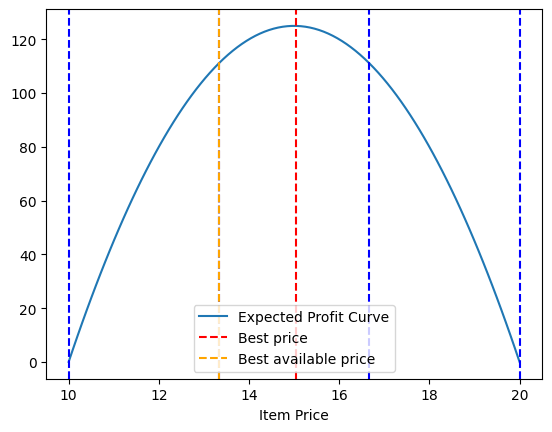

In [12]:
all_prices = np.linspace(10, 20, 100)
expected_profit_curve = n_customers*conversion_probability(all_prices)*(all_prices-cost)
best_price = all_prices[np.argmax(expected_profit_curve)]
discretized_profits = n_customers*conversion_probability(prices)*(prices-cost)
best_discretized_price = prices[np.argmax(discretized_profits)]

plt.figure()
plt.plot(all_prices, expected_profit_curve, label='Expected Profit Curve')
plt.axvline(best_price, color='red', linestyle='--', label='Best price')
for price in prices:
    plt.axvline(price, color='blue', linestyle='--')
plt.axvline(best_discretized_price, color='orange', linestyle='--', label='Best available price')
plt.xlabel('Item Price')
plt.legend()
plt.show()

Reward difference between optimal available price and true price: 7.799746199367419


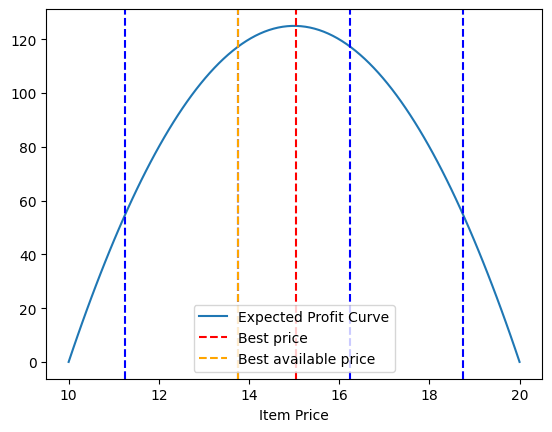

In [13]:
def cover(p_min,p_max,K):
    return np.linspace(p_min, p_max, K, endpoint=False) + (p_max - p_min) / (2 * K)

K = 4
prices = cover(10,20,K)
cost = 10
conversion_probability = lambda p: 1-p/20

n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

reward_function = lambda price, n_sales: (price-cost)*n_sales
expected_reward_function = lambda price, n_customers: n_customers*conversion_probability(price)*(price-cost)
all_prices = np.linspace(10, 20, 100)
expected_profit_curve = n_customers*conversion_probability(all_prices)*(all_prices-cost)
best_price = all_prices[np.argmax(expected_profit_curve)]
discretized_profits = n_customers*conversion_probability(prices)*(prices-cost)
best_discretized_price = prices[np.argmax(discretized_profits)]

gap = expected_reward_function(best_price,n_customers)-expected_reward_function(best_discretized_price,n_customers)
print("Reward difference between optimal available price and true price:",gap)

plt.figure()
plt.plot(all_prices, expected_profit_curve, label='Expected Profit Curve')
plt.axvline(best_price, color='red', linestyle='--', label='Best price')
for price in prices:
    plt.axvline(price, color='blue', linestyle='--')
plt.axvline(best_discretized_price, color='orange', linestyle='--', label='Best available price')
plt.xlabel('Item Price')
plt.legend()
plt.show()

### Let's test it

Range: 875.0


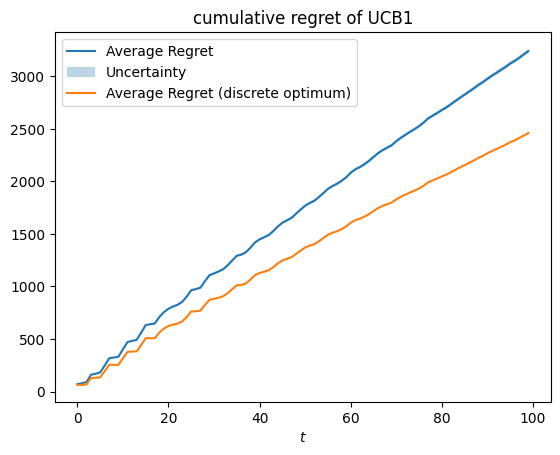

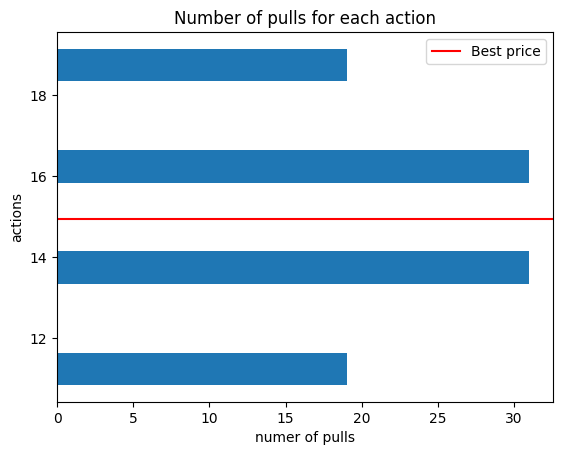

In [14]:
T = 100
K = 4

cover_prices = cover(10,20,K)
all_prices = cover(10,20,100)
cost = 10
conversion_probability = lambda p: 1-p/20

n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

reward_function = lambda price, n_sales: (price-cost)*n_sales
# standard UCB works with rewards in [0,1]
# here we need to use a different range
# Notice that the minimum reward is 0 (we do not sell at less than cost)
maximum_profit = reward_function(max(cover_prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer
print("Range:",maximum_profit)

# let's compute the clairvoyant
profit_curve = reward_function(all_prices, n_customers*conversion_probability(all_prices))
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)
# for the analysis only
best_available_price_index = np.argmax(reward_function(cover_prices, n_customers*conversion_probability(cover_prices)))
best_available_price = cover_prices[best_available_price_index]
expected_discretized_clairvoyant_rewards = np.repeat(reward_function(best_available_price, n_customers*conversion_probability(best_available_price)), T)

n_trials = 100

regret_per_trial = []
discretized_regret_per_trial = [] 

for seed in range(n_trials):
    np.random.seed(seed)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
    ucb_agent = UCB1Agent(K, T, range=maximum_profit)

    agent_rewards = []

    for t in range(T):
        pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
        p_t = cover_prices[pi_t] # I get the actual price
        d_t, r_t = env.round(p_t, n_customers)
        ucb_agent.update(r_t)

        agent_rewards.append(r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    discretized_regret_per_trial.append(cumulative_discretized_regret)


regret_per_trial = np.array(regret_per_trial)
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

discretized_regret_per_trial = np.array(discretized_regret_per_trial)
discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of UCB1')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), discretized_average_regret, label='Average Regret (discrete optimum)')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.figure()
plt.barh(cover_prices, ucb_agent.N_pulls)
plt.axhline(best_price, color='red', label='Best price')
plt.ylabel('actions')
plt.xlabel('numer of pulls')
plt.legend()
plt.title('Number of pulls for each action')
plt.show()

### Notice that 100 rounds are not enough to coverge to the optimal available arm. 
### Why? What do you expect if you increase the number of rounds?

Range: 875.0


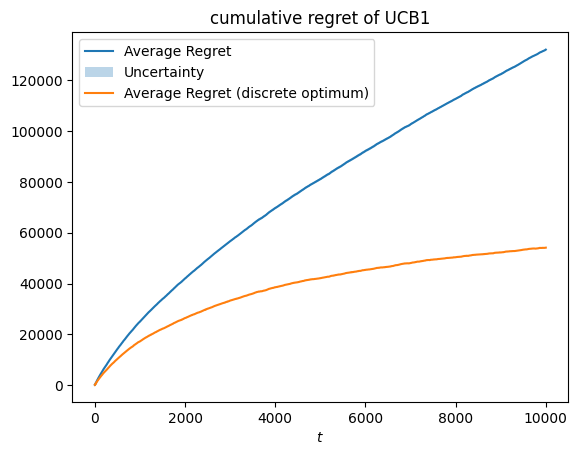

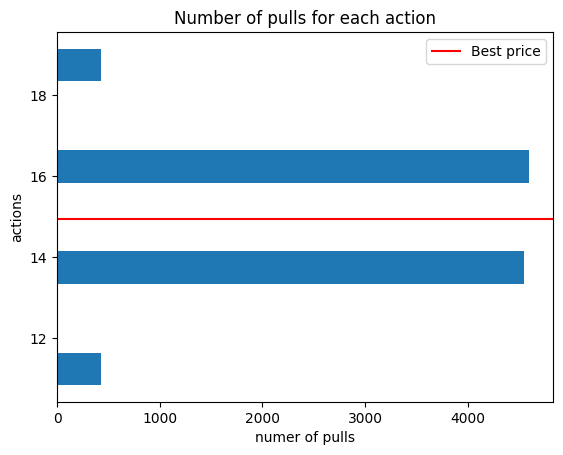

In [15]:
T = 10000
K = 4

cover_prices = cover(10,20,K)
all_prices = cover(10,20,100)
cost = 10
conversion_probability = lambda p: 1-p/20

n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

reward_function = lambda price, n_sales: (price-cost)*n_sales
# standard UCB works with rewards in [0,1]
# here we need to use a different range
# Notice that the minimum reward is 0 (we do not sell at less than cost)
maximum_profit = reward_function(max(cover_prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer
print("Range:",maximum_profit)

# let's compute the clairvoyant
profit_curve = reward_function(all_prices, n_customers*conversion_probability(all_prices))
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)
best_available_price_index = np.argmax(reward_function(cover_prices, n_customers*conversion_probability(cover_prices)))
best_available_price = cover_prices[best_available_price_index]
expected_discretized_clairvoyant_rewards = np.repeat(reward_function(best_available_price, n_customers*conversion_probability(best_available_price)), T)

n_trials = 10

regret_per_trial = []
discretized_regret_per_trial = [] 

for seed in range(n_trials):
    np.random.seed(seed)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
    ucb_agent = UCB1Agent(K, T, range=maximum_profit)

    agent_rewards = []

    for t in range(T):
        pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
        p_t = cover_prices[pi_t] # I get the actual price
        d_t, r_t = env.round(p_t, n_customers)
        ucb_agent.update(r_t)

        agent_rewards.append(r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    discretized_regret_per_trial.append(cumulative_discretized_regret)


regret_per_trial = np.array(regret_per_trial)
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

discretized_regret_per_trial = np.array(discretized_regret_per_trial)
discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of UCB1')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), discretized_average_regret, label='Average Regret (discrete optimum)')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.figure()
plt.barh(cover_prices, ucb_agent.N_pulls)
plt.axhline(best_price, color='red', label='Best price')
plt.ylabel('actions')
plt.xlabel('numer of pulls')
plt.legend()
plt.title('Number of pulls for each action')
plt.show()

### Idea: use a very large $K$. This way the optimal price belongs to the cover.

Range: 994.9999999999999
Utility gap: 0.0


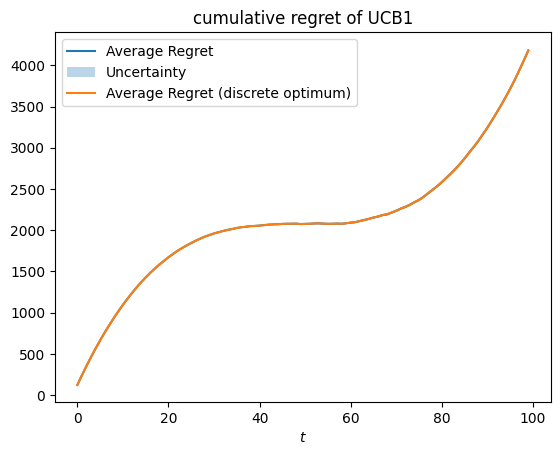

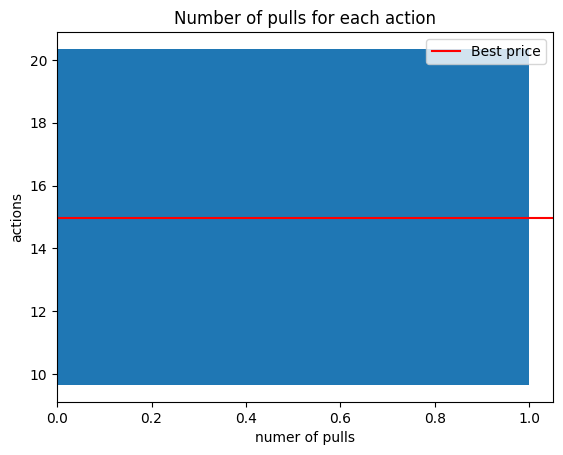

In [16]:
T = 100
K = 100 # very large numer, same used to compute the optimum

cover_prices = cover(10,20,K)
all_prices = cover(10,20,100)
cost = 10
conversion_probability = lambda p: 1-p/20

n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

reward_function = lambda price, n_sales: (price-cost)*n_sales
# standard UCB works with rewards in [0,1]
# here we need to use a different range
# Notice that the minimum reward is 0 (we do not sell at less than cost)
maximum_profit = reward_function(max(cover_prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer
print("Range:",maximum_profit)

# let's compute the clairvoyant
profit_curve = reward_function(all_prices, n_customers*conversion_probability(all_prices))
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)
best_available_price_index = np.argmax(reward_function(cover_prices, n_customers*conversion_probability(cover_prices)))
best_available_price = cover_prices[best_available_price_index]
expected_discretized_clairvoyant_rewards = np.repeat(reward_function(best_available_price, n_customers*conversion_probability(best_available_price)), T)
print("Utility gap:",expected_clairvoyant_rewards[0]-expected_discretized_clairvoyant_rewards[0])

n_trials = 100

regret_per_trial = []
discretized_regret_per_trial = [] 

for seed in range(n_trials):
    np.random.seed(seed)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
    ucb_agent = UCB1Agent(K, T, range=maximum_profit)

    agent_rewards = []

    for t in range(T):
        pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
        p_t = cover_prices[pi_t] # I get the actual price
        d_t, r_t = env.round(p_t, n_customers)
        ucb_agent.update(r_t)

        agent_rewards.append(r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    discretized_regret_per_trial.append(cumulative_discretized_regret)


regret_per_trial = np.array(regret_per_trial)
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

discretized_regret_per_trial = np.array(discretized_regret_per_trial)
discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of UCB1')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), discretized_average_regret, label='Average Regret (discrete optimum)')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.figure()
plt.barh(cover_prices, ucb_agent.N_pulls)
plt.axhline(best_price, color='red', label='Best price')
plt.ylabel('actions')
plt.xlabel('numer of pulls')
plt.legend()
plt.title('Number of pulls for each action')
plt.show()

### What happens if we increase the number of rounds?

Range: 994.9999999999999
Utility gap: 0.0


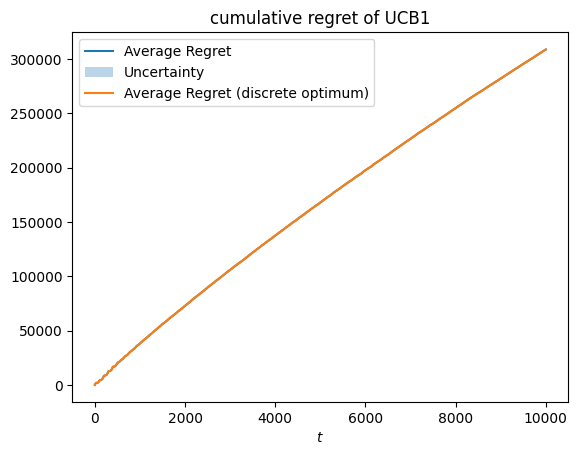

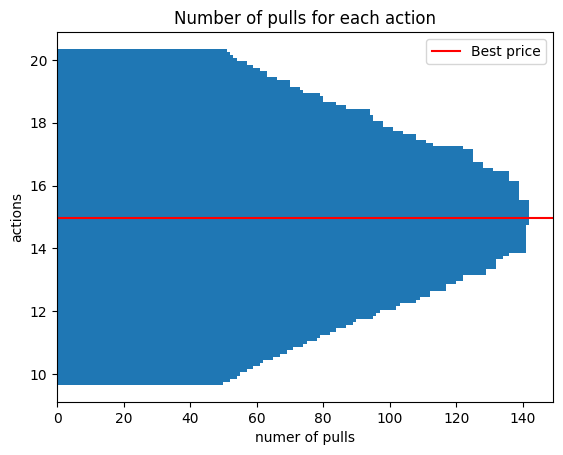

In [17]:
T = 10000
K = 100 # very large numer, same used to compute the optimum

cover_prices = cover(10,20,K)
all_prices = cover(10,20,100)
cost = 10
conversion_probability = lambda p: 1-p/20

n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

reward_function = lambda price, n_sales: (price-cost)*n_sales
# standard UCB works with rewards in [0,1]
# here we need to use a different range
# Notice that the minimum reward is 0 (we do not sell at less than cost)
maximum_profit = reward_function(max(cover_prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer
print("Range:",maximum_profit)

# let's compute the clairvoyant
profit_curve = reward_function(all_prices, n_customers*conversion_probability(all_prices))
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)
best_available_price_index = np.argmax(reward_function(cover_prices, n_customers*conversion_probability(cover_prices)))
best_available_price = cover_prices[best_available_price_index]
expected_discretized_clairvoyant_rewards = np.repeat(reward_function(best_available_price, n_customers*conversion_probability(best_available_price)), T)
print("Utility gap:",expected_clairvoyant_rewards[0]-expected_discretized_clairvoyant_rewards[0])

n_trials = 10

regret_per_trial = []
discretized_regret_per_trial = [] 

for seed in range(n_trials):
    np.random.seed(seed)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
    ucb_agent = UCB1Agent(K, T, range=maximum_profit)

    agent_rewards = []

    for t in range(T):
        pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
        p_t = cover_prices[pi_t] # I get the actual price
        d_t, r_t = env.round(p_t, n_customers)
        ucb_agent.update(r_t)

        agent_rewards.append(r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    discretized_regret_per_trial.append(cumulative_discretized_regret)


regret_per_trial = np.array(regret_per_trial)
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

discretized_regret_per_trial = np.array(discretized_regret_per_trial)
discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of UCB1')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), discretized_average_regret, label='Average Regret (discrete optimum)')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.figure()
plt.barh(cover_prices, ucb_agent.N_pulls)
plt.axhline(best_price, color='red', label='Best price')
plt.ylabel('actions')
plt.xlabel('numer of pulls')
plt.legend()
plt.title('Number of pulls for each action')
plt.show()

### This discretization attains a very large regret unless we have a very large number of rounds.
### In general, given $T$, we need to find a good discretization (expressed as $K$ or $\epsilon$). 

### The expected regret is:
### $$ R(T) = T\Delta +O(\sqrt{KT\log(T)})$$
### where $\Delta$ is the difference between the utility of the best price and the one of the best discretized price.
### $\Delta$ (generally) decreases with K, introducing a tradeoff

### Before looking at the theory, let us analyze this tradeoff in an example:
- ### we slightly change the demand curve (more on this later)
- ### we use T=10000

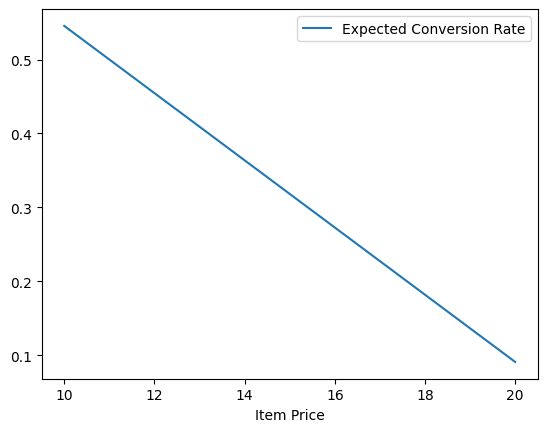

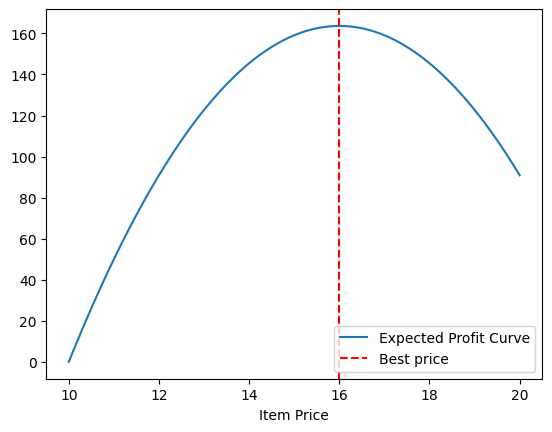

In [18]:
cost = 10
conversion_probability = lambda p: 1-p/22
# conversion_probability = lambda p: 1 / (1 + np.exp(0.4 * (p - 16)))
# conversion_probability = lambda p: 12*np.exp(-0.4*p)
# conversion_probability = lambda p: 12*np.exp(-0.3*p)
n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

all_prices = np.linspace(10, 20, 1000)
expected_profit_curve = n_customers*conversion_probability(all_prices)*(all_prices-cost)
best_price = all_prices[np.argmax(expected_profit_curve)]

plt.figure()
plt.plot(all_prices, conversion_probability(all_prices), label='Expected Conversion Rate')
plt.xlabel('Item Price')
plt.legend()
plt.show()

plt.figure()
plt.plot(all_prices, expected_profit_curve, label='Expected Profit Curve')
plt.axvline(best_price, color='red', linestyle='--', label='Best price')
plt.xlabel('Item Price')
plt.legend()
plt.show()

## Let us observe the cumulative regret different Ks

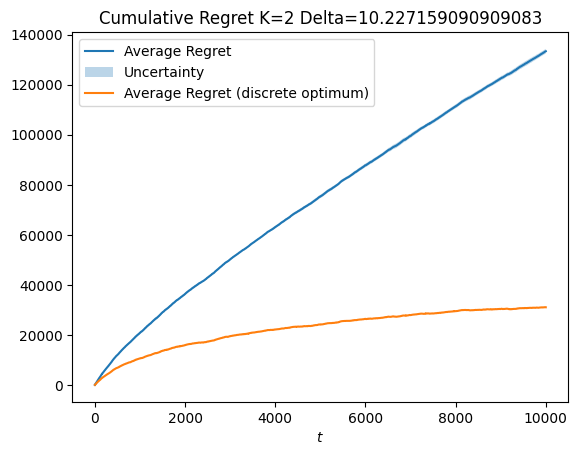

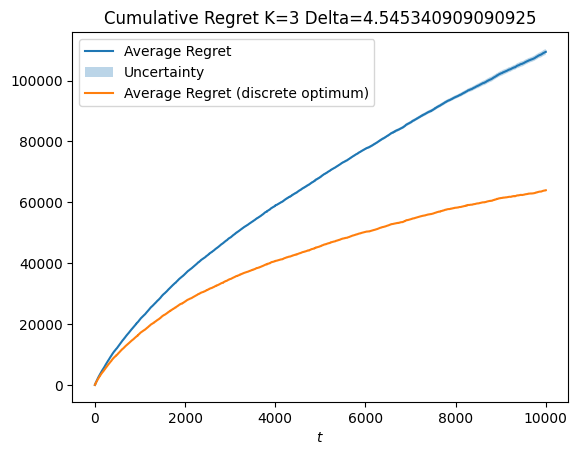

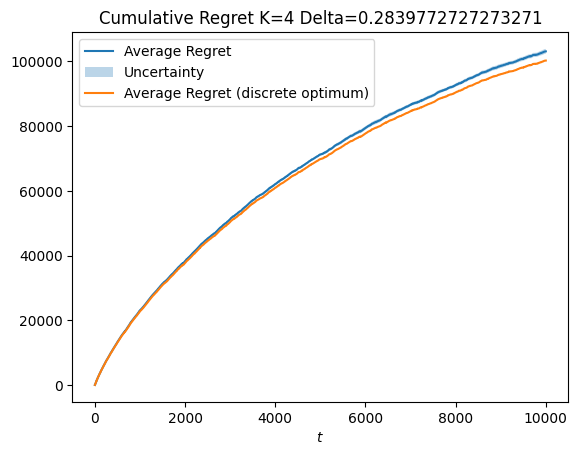

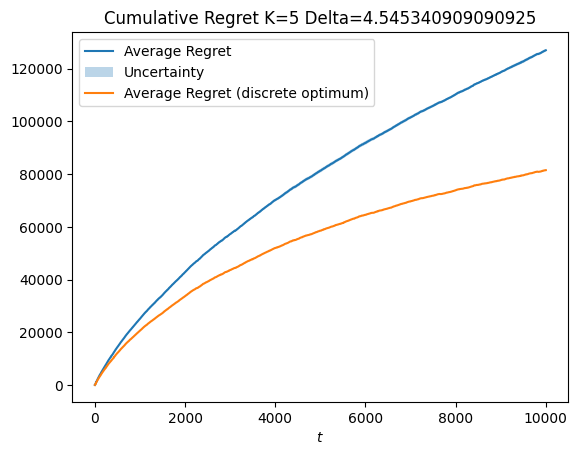

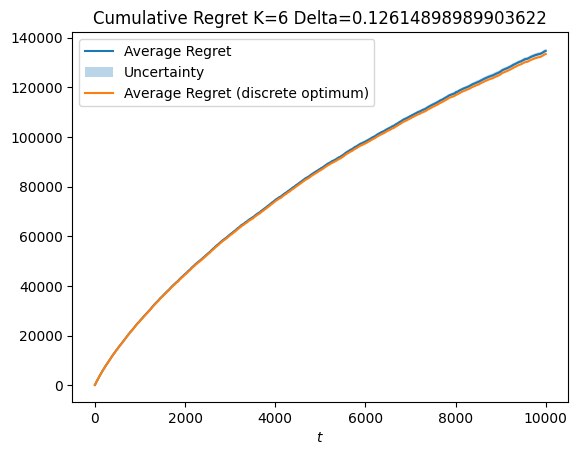

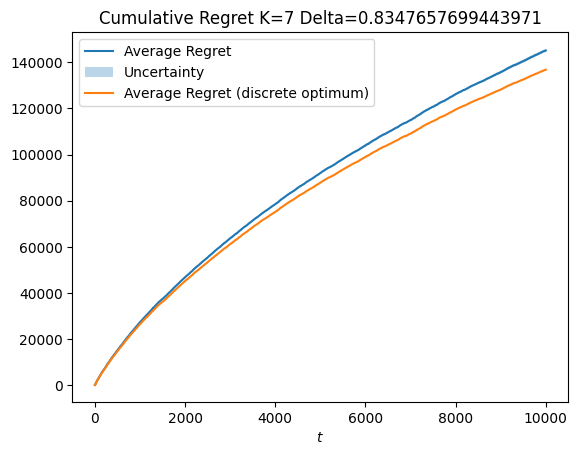

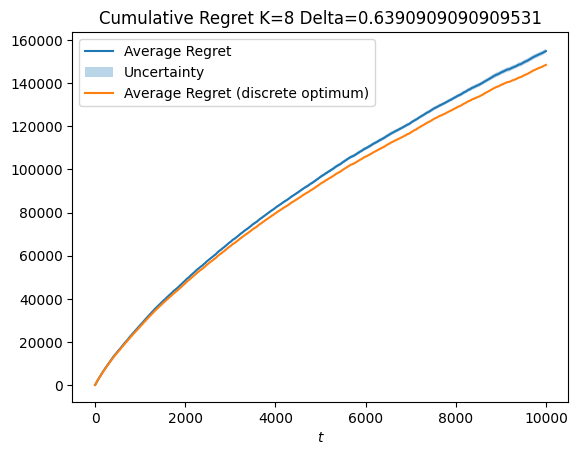

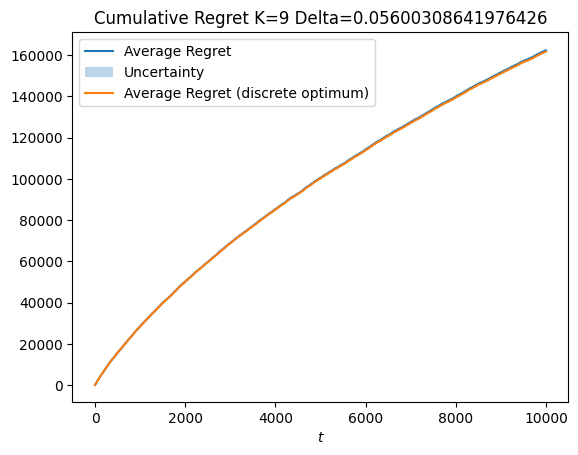

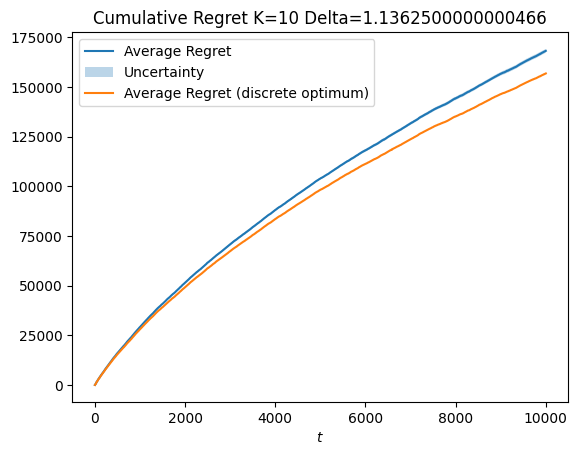

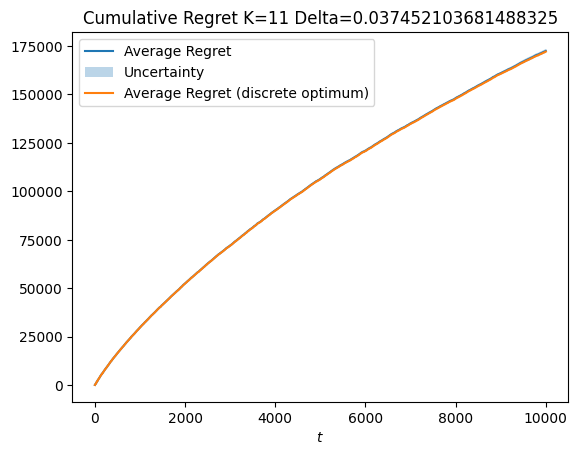

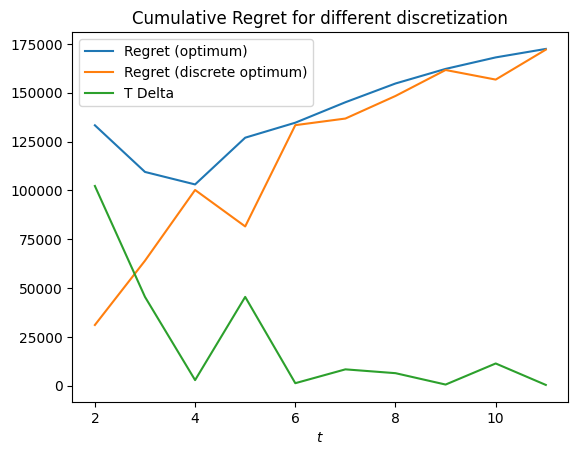

In [ ]:
T = 10000
Ks = np.arange(10)+2

all_prices = cover(10,20,1000)
cost = 10
conversion_probability = lambda p: 1-p/22
n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)
reward_function = lambda price, n_sales: (price-cost)*n_sales

# let's compute the clairvoyant
profit_curve = reward_function(all_prices, n_customers*conversion_probability(all_prices))
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

n_trials = 10
regrets_for_ks = []
discretized_regrets_for_ks = []
delta_for_ks = []
for K in Ks:
    cover_prices = cover(10,20,K)
    maximum_profit = reward_function(max(cover_prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer

    best_available_price_index = np.argmax(reward_function(cover_prices, n_customers*conversion_probability(cover_prices)))
    best_available_price = cover_prices[best_available_price_index]
    expected_discretized_clairvoyant_rewards = np.repeat(reward_function(best_available_price, n_customers*conversion_probability(best_available_price)), T)
    delta = expected_clairvoyant_rewards[0]-expected_discretized_clairvoyant_rewards[0]
    delta_for_ks.append(delta)

    regret_per_trial = []
    discretized_regret_per_trial = [] 

    for seed in range(n_trials):
        np.random.seed(seed)
        env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
        ucb_agent = UCB1Agent(K, T, range=maximum_profit)

        agent_rewards = []
        for t in range(T):
            pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
            p_t = cover_prices[pi_t] # I get the actual price
            d_t, r_t = env.round(p_t, n_customers)
            ucb_agent.update(r_t)

            agent_rewards.append(r_t)

        cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
        cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
        regret_per_trial.append(cumulative_regret)
        discretized_regret_per_trial.append(cumulative_discretized_regret)

    regret_per_trial = np.array(regret_per_trial)
    average_regret = regret_per_trial.mean(axis=0)
    regret_sd = regret_per_trial.std(axis=0)

    regrets_for_ks.append(average_regret[-1])

    discretized_regret_per_trial = np.array(discretized_regret_per_trial)
    discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

    discretized_regrets_for_ks.append(discretized_average_regret[-1])

    plt.plot(np.arange(T), average_regret, label='Average Regret')
    plt.title('Cumulative Regret K={} Delta={}'.format(K, delta))
    plt.fill_between(np.arange(T),
                    average_regret-regret_sd/np.sqrt(n_trials),
                    average_regret+regret_sd/np.sqrt(n_trials),
                    alpha=0.3,
                    label='Uncertainty')
    plt.plot(np.arange(T), discretized_average_regret, label='Average Regret (discrete optimum)')
    # notice that the at every t, the difference between the two regrets is t*Delta (up to estimationuncerntainty)
    plt.xlabel('$t$')
    plt.legend()
    plt.show()

plt.plot(Ks, regrets_for_ks, label='Regret (optimum)')
plt.plot(Ks, discretized_regrets_for_ks, label='Regret (discrete optimum)')
plt.plot(Ks, T*np.array(delta_for_ks), label='T Delta')
plt.title('Cumulative Regret for different discretization')
plt.xlabel('$K$')
plt.legend()
plt.show()

# plt.figure()
# plt.barh(cover_prices, ucb_agent.N_pulls)
# plt.axhline(best_price, color='red', label='Best price')
# plt.ylabel('actions')
# plt.xlabel('numer of pulls')
# plt.legend()
# plt.title('Number of pulls for each action')
# plt.show()

### This analysis suggests $K=4$. However, we cannot use it in practice: we do not know the function and we cannot run multiple trials to search for K.
### It is an hyperparameter that must be optimized for the worst case using our Lipschitz assumtion.
### Theory says to use:
### $$ K=\frac{1}{\epsilon} =  \frac{1}{T^{-1/3}} =  T^{1/3},$$
### which provides a regret of $\widetilde{\mathcal{O}}(T^{2/3})$ in the worst case


In [20]:
epsilon = T**(-0.33)
K = int(1/epsilon)
K

20

K: 20
Range: 975.0
Utility gap: 0.2839772727273271


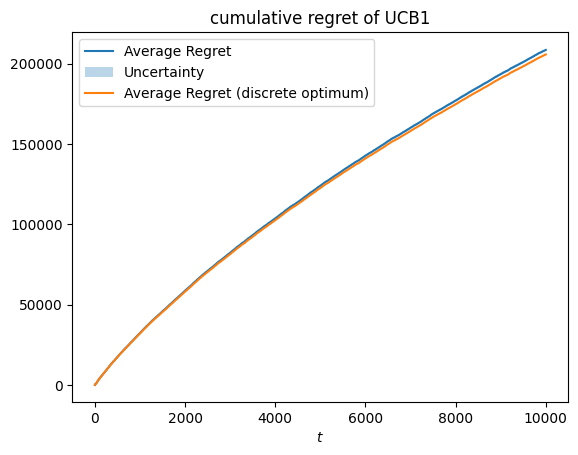

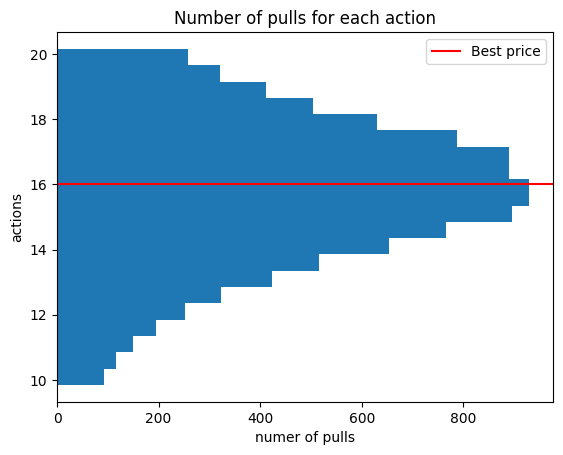

In [21]:
T = 10000
epsilon = T**(-0.33)
K = int(1/epsilon)
print("K:",K)

cover_prices = cover(10,20,K)
all_prices = cover(10,20,1000)
cost = 10
conversion_probability = lambda p: 1-p/22

n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

reward_function = lambda price, n_sales: (price-cost)*n_sales
maximum_profit = reward_function(max(cover_prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer
print("Range:",maximum_profit)

# let's compute the clairvoyant
profit_curve = reward_function(all_prices, n_customers*conversion_probability(all_prices))
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)
best_available_price_index = np.argmax(reward_function(cover_prices, n_customers*conversion_probability(cover_prices)))
best_available_price = cover_prices[best_available_price_index]
expected_discretized_clairvoyant_rewards = np.repeat(reward_function(best_available_price, n_customers*conversion_probability(best_available_price)), T)
print("Utility gap:",expected_clairvoyant_rewards[0]-expected_discretized_clairvoyant_rewards[0])

n_trials = 10

regret_per_trial = []
discretized_regret_per_trial = [] 

for seed in range(n_trials):
    np.random.seed(seed)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
    ucb_agent = UCB1Agent(K, T, range=maximum_profit)

    agent_rewards = []

    for t in range(T):
        pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
        p_t = cover_prices[pi_t] # I get the actual price
        d_t, r_t = env.round(p_t, n_customers)
        ucb_agent.update(r_t)

        agent_rewards.append(r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    discretized_regret_per_trial.append(cumulative_discretized_regret)


regret_per_trial = np.array(regret_per_trial)
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

discretized_regret_per_trial = np.array(discretized_regret_per_trial)
discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of UCB1')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), discretized_average_regret, label='Average Regret (discrete optimum)')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.figure()
plt.barh(cover_prices, ucb_agent.N_pulls)
plt.axhline(best_price, color='red', label='Best price')
plt.ylabel('actions')
plt.xlabel('numer of pulls')
plt.legend()
plt.title('Number of pulls for each action')
plt.show()

### What changes in the empirical analysis (for different $K$) if we use the original demand curve?

[12.5 17.5]
[11.66666667 15.         18.33333333]
[11.25 13.75 16.25 18.75]
[11. 13. 15. 17. 19.]
[10.83333333 12.5        14.16666667 15.83333333 17.5        19.16666667]
[10.71428571 12.14285714 13.57142857 15.         16.42857143 17.85714286
 19.28571429]
[10.625 11.875 13.125 14.375 15.625 16.875 18.125 19.375]
[10.55555556 11.66666667 12.77777778 13.88888889 15.         16.11111111
 17.22222222 18.33333333 19.44444444]
[10.5 11.5 12.5 13.5 14.5 15.5 16.5 17.5 18.5 19.5]
[10.45454545 11.36363636 12.27272727 13.18181818 14.09090909 15.
 15.90909091 16.81818182 17.72727273 18.63636364 19.54545455]
[10.41666667 11.25       12.08333333 12.91666667 13.75       14.58333333
 15.41666667 16.25       17.08333333 17.91666667 18.75       19.58333333]
[10.38461538 11.15384615 11.92307692 12.69230769 13.46153846 14.23076923
 15.         15.76923077 16.53846154 17.30769231 18.07692308 18.84615385
 19.61538462]


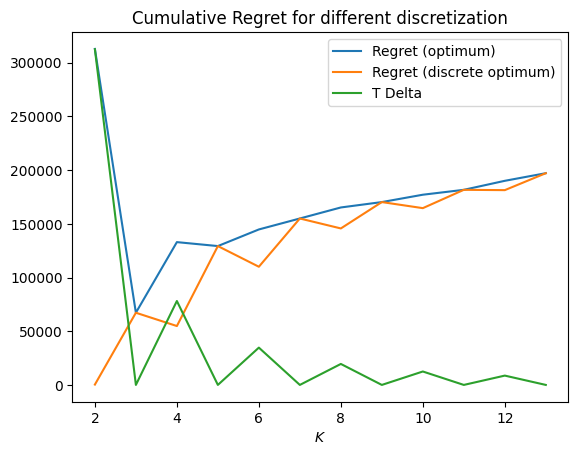

In [25]:
T = 10000
Ks = np.arange(12)+2

all_prices = cover(10,20,1000)
cost = 10
conversion_probability = lambda p: 1-p/20
n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)
reward_function = lambda price, n_sales: (price-cost)*n_sales

# let's compute the clairvoyant
profit_curve = reward_function(all_prices, n_customers*conversion_probability(all_prices))
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

n_trials = 2
regrets_for_ks = []
discretized_regrets_for_ks = []
delta_for_ks = []
for K in Ks:
    cover_prices = cover(10,20,K)
    print(cover_prices)
    maximum_profit = reward_function(max(cover_prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer

    best_available_price_index = np.argmax(reward_function(cover_prices, n_customers*conversion_probability(cover_prices)))
    best_available_price = cover_prices[best_available_price_index]
    expected_discretized_clairvoyant_rewards = np.repeat(reward_function(best_available_price, n_customers*conversion_probability(best_available_price)), T)
    delta = expected_clairvoyant_rewards[0]-expected_discretized_clairvoyant_rewards[0]
    delta_for_ks.append(delta)

    regret_per_trial = []
    discretized_regret_per_trial = [] 

    for seed in range(n_trials):
        np.random.seed(seed)
        env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
        ucb_agent = UCB1Agent(K, T, range=maximum_profit)

        agent_rewards = []
        for t in range(T):
            pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
            p_t = cover_prices[pi_t] # I get the actual price
            d_t, r_t = env.round(p_t, n_customers)
            ucb_agent.update(r_t)

            agent_rewards.append(r_t)

        cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
        cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
        regret_per_trial.append(cumulative_regret)
        discretized_regret_per_trial.append(cumulative_discretized_regret)

    regret_per_trial = np.array(regret_per_trial)
    average_regret = regret_per_trial.mean(axis=0)
    regret_sd = regret_per_trial.std(axis=0)

    regrets_for_ks.append(average_regret[-1])

    discretized_regret_per_trial = np.array(discretized_regret_per_trial)
    discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

    discretized_regrets_for_ks.append(discretized_average_regret[-1])

plt.plot(Ks, regrets_for_ks, label='Regret (optimum)')
plt.plot(Ks, discretized_regrets_for_ks, label='Regret (discrete optimum)')
plt.plot(Ks, T*np.array(delta_for_ks), label='T Delta')
plt.title('Cumulative Regret for different discretization')
plt.xlabel('$K$')
plt.legend()
plt.show()

### What do we do if $n_t$ is not constant over time?

K: 20


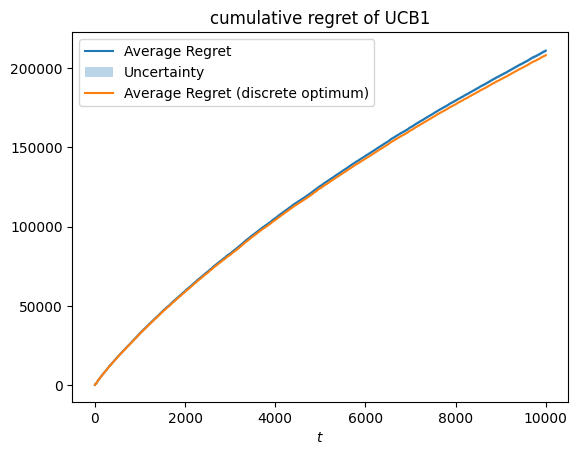

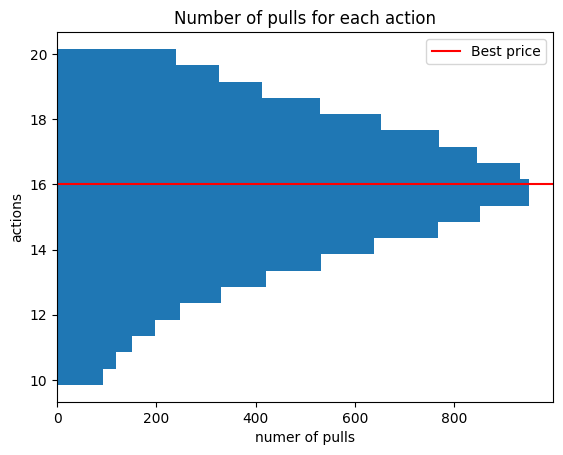

In [37]:
T = 10000
epsilon = T**(-0.33)
K = int(1/epsilon)
print("K:",K)

cover_prices = cover(10,20,K)
all_prices = cover(10,20,1000)
cost = 10
conversion_probability = lambda p: 1-p/22

n_customers = n_t = np.random.poisson(lam=100, size=T) # variable number of customers, 100 in expectation

max_reward_for_customer = cover_prices[-1]-cost # equal to the margin

# let's compute the clairvoyant
# careful: the reward is not the same every t
profit_curve = conversion_probability(all_prices)*(all_prices-cost) # normalized by n_t
best_price_index = np.argmax(profit_curve)
best_price = all_prices[best_price_index]
expected_clairvoyant_rewards = profit_curve[best_price_index]*n_customers

best_available_price_index = np.argmax(conversion_probability(cover_prices)*(cover_prices-cost))
best_available_price = cover_prices[best_available_price_index]
expected_discretized_clairvoyant_rewards = conversion_probability(best_available_price)*(best_available_price-cost)*n_customers

n_trials = 10

regret_per_trial = []
discretized_regret_per_trial = [] 

for seed in range(n_trials):
    np.random.seed(seed)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)
    ucb_agent = UCB1Agent(K, T, range=max_reward_for_customer)

    agent_rewards = []

    for t in range(T):
        pi_t = ucb_agent.pull_arm() ## the agent returns the index!!
        p_t = cover_prices[pi_t] # I get the actual price
        d_t, r_t = env.round(p_t, n_customers[t])
        ucb_agent.update(r_t/n_customers[t])

        agent_rewards.append(r_t)
        # agent_rewards.append(conversion_probability(p_t)*(p_t-cost)*n_customers[t])

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    cumulative_discretized_regret = np.cumsum(expected_discretized_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)
    discretized_regret_per_trial.append(cumulative_discretized_regret)


regret_per_trial = np.array(regret_per_trial)
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

discretized_regret_per_trial = np.array(discretized_regret_per_trial)
discretized_average_regret = discretized_regret_per_trial.mean(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of UCB1')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), discretized_average_regret, label='Average Regret (discrete optimum)')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.figure()
plt.barh(cover_prices, ucb_agent.N_pulls)
plt.axhline(best_price, color='red', label='Best price')
plt.ylabel('actions')
plt.xlabel('numer of pulls')
plt.legend()
plt.title('Number of pulls for each action')
plt.show()

In [34]:
ucb_agent.N_pulls[10]

np.float64(9950.0)